In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import kruskal, mannwhitneyu
import os, warnings

warnings.filterwarnings('ignore')

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../figures/exploratory", exist_ok=True)
os.makedirs("../figures/final", exist_ok=True)

print("Libraries loaded")

Libraries loaded


In [2]:
print("Loading HMP2 taxonomic profiles...")
hmp2_raw = pd.read_csv(
    "../data/raw/HMP2_taxonomic_profiles.tsv.gz",
    sep='\t', index_col=0, compression='gzip'
)

hmp2 = hmp2_raw.T
print(f"Raw shape: {hmp2.shape} (samples × features)")

meta = pd.read_csv("../data/raw/HMP2_metadata.csv", low_memory=False)
meta_wgs = meta[meta['data_type'] == 'metagenomics'].copy()
meta_wgs = meta_wgs.set_index('External ID')

print(f"\nMetadata samples: {len(meta_wgs)}")
print(f"  CD:     {(meta_wgs['diagnosis']=='CD').sum()}")
print(f"  UC:     {(meta_wgs['diagnosis']=='UC').sum()}")
print(f"  nonIBD: {(meta_wgs['diagnosis']=='nonIBD').sum()}")
print(f"  Unique patients: {meta_wgs['Participant ID'].nunique()}")
print(f"  Weeks: {meta_wgs['week_num'].min():.0f}"
      f" to {meta_wgs['week_num'].max():.0f}")

matched = hmp2.index.intersection(meta_wgs.index)
hmp2 = hmp2.loc[matched]
meta_wgs = meta_wgs.loc[matched]
print(f"\nMatched samples: {len(matched)} (100%)")

meta_wgs.to_csv("../data/processed/HMP2_meta_matched.csv")

Loading HMP2 taxonomic profiles...
Raw shape: (1638, 1479) (samples × features)

Metadata samples: 1638
  CD:     750
  UC:     459
  nonIBD: 429
  Unique patients: 130
  Weeks: 0 to 57

Matched samples: 1638 (100%)


In [3]:
print(hmp2.isna().sum().sum())

0


In [4]:
print("Filtering to species level...")

before = hmp2.shape[1]

if hmp2.columns.str.contains('s__').any():
    
    sp_mask = hmp2.columns.str.contains('s__')
    hmp2 = hmp2.loc[:, sp_mask]

    hmp2.columns = hmp2.columns.str.split('s__').str[-1]

    hmp2 = hmp2.loc[:, hmp2.columns != '']

    hmp2 = hmp2.groupby(hmp2.columns, axis=1).sum()

    print(f"Species columns: {before} → {hmp2.shape[1]}")
    print("Example species:", hmp2.columns[:5].tolist())

else:
    print("No species prefix found — assuming already clean")
    print("Columns:", hmp2.columns[:5].tolist())

Filtering to species level...
Species columns: 1479 → 1106
Example species: ['Abiotrophia_defectiva', 'Abiotrophia_defectiva|t__GCF_000160075', 'Acidaminococcus_fermentans', 'Acidaminococcus_fermentans|t__GCF_000025305', 'Acidaminococcus_intestini']


In [5]:
hmp2_species = hmp2.copy()

hmp2_genus = hmp2_species.copy()
hmp2_genus.columns = [c.split()[0] for c in hmp2_genus.columns]
hmp2_genus = hmp2_genus.groupby(hmp2_genus.columns, axis=1).sum()

In [6]:
print(hmp2.shape)
print(hmp2.columns[:10])

(1638, 1106)
Index(['Abiotrophia_defectiva', 'Abiotrophia_defectiva|t__GCF_000160075',
       'Acidaminococcus_fermentans',
       'Acidaminococcus_fermentans|t__GCF_000025305',
       'Acidaminococcus_intestini',
       'Acidaminococcus_intestini|t__GCF_000230275',
       'Acidaminococcus_sp_BV3L6', 'Acidaminococcus_sp_BV3L6|t__GCF_000468835',
       'Acidaminococcus_sp_HPA0509',
       'Acidaminococcus_sp_HPA0509|t__GCF_000411395'],
      dtype='object', name='#SampleID')


In [7]:
print("Cleaning strain annotations...")

hmp2.columns = hmp2.columns.str.split('|').str[0]

hmp2 = hmp2.groupby(hmp2.columns, axis=1).sum()

print("Final shape:", hmp2.shape)
print("Example species:", hmp2.columns[:10].tolist())

Cleaning strain annotations...
Final shape: (1638, 572)
Example species: ['Abiotrophia_defectiva', 'Acidaminococcus_fermentans', 'Acidaminococcus_intestini', 'Acidaminococcus_sp_BV3L6', 'Acidaminococcus_sp_HPA0509', 'Acidaminococcus_unclassified', 'Acinetobacter_lwoffii', 'Acinetobacter_unclassified', 'Acinetobacter_ursingii', 'Actinobacillus_unclassified']


In [8]:
print("Duplicate species:", hmp2.columns.duplicated().sum())

print("Missing values:", hmp2.isna().sum().sum())

print("Min sample sum:", hmp2.sum(axis=1).min())

Duplicate species: 0
Missing values: 0
Min sample sum: 0.0


In [9]:
print("Splitting into 3 conditions...")

common = hmp2.index.intersection(meta_wgs.index)

hmp2 = hmp2.loc[common]
meta_wgs = meta_wgs.loc[common]

cd_idx = meta_wgs[meta_wgs['diagnosis'] == 'CD'].index
uc_idx = meta_wgs[meta_wgs['diagnosis'] == 'UC'].index
healthy_idx = meta_wgs[meta_wgs['diagnosis'] == 'nonIBD'].index

hmp2_cd = hmp2.loc[cd_idx]
hmp2_uc = hmp2.loc[uc_idx]
hmp2_healthy = hmp2.loc[healthy_idx]

print(f"CD: {hmp2_cd.shape}")
print(f"UC: {hmp2_uc.shape}")
print(f"Healthy: {hmp2_healthy.shape}")

Splitting into 3 conditions...
CD: (750, 572)
UC: (459, 572)
Healthy: (429, 572)


In [10]:
assert all(hmp2_cd.index == meta_wgs.loc[cd_idx].index)
assert all(hmp2_uc.index == meta_wgs.loc[uc_idx].index)
assert all(hmp2_healthy.index == meta_wgs.loc[healthy_idx].index)

print("Index alignment confirmed")

Index alignment confirmed


In [11]:
meta_wgs['diagnosis'] = meta_wgs['diagnosis'].replace({'nonIBD': 'Healthy'})

In [12]:
healthy_idx = meta_wgs[meta_wgs['diagnosis'] == 'Healthy'].index

In [13]:
def preprocess(df, condition_name, prevalence_thresh=0.20, abundance_thresh=1e-4):
    print(f"\n {condition_name} ")
    print("Start:", df.shape)

    if df.values.max() > 1:
        df = df / 100.0

    df = df.loc[:, df.sum(axis=0) > 0]

    prevalence = (df > 0).mean(axis=0)
    df = df.loc[:, prevalence >= prevalence_thresh]
    print("After prevalence:", df.shape)

    mean_abundance = df.mean(axis=0)
    df = df.loc[:, mean_abundance >= abundance_thresh]
    print("After abundance:", df.shape)

    df = df.loc[df.sum(axis=1) > 0]

    df_norm = df.div(df.sum(axis=1), axis=0)

    df_pseudo = df_norm + 1e-6
    log_df = np.log(df_pseudo)
    df_clr = log_df.sub(log_df.mean(axis=1), axis=0)

    df_counts = (df_norm * 10000).round().astype(int)
    df_counts = df_counts.loc[:, df_counts.sum(axis=0) > 0]

    df_norm.to_csv(f"../data/processed/{condition_name}_normalized.csv")
    df_clr.to_csv(f"../data/processed/{condition_name}_CLR.csv")
    df_counts.to_csv(f"../data/processed/{condition_name}_counts.tsv", sep='\t')

    print("Final:", df_norm.shape)
    print("Saved: normalized, CLR, counts")

    return df_norm, df_clr, df_counts

In [14]:
cd_norm, cd_clr, cd_counts = preprocess(hmp2_cd, "CD")
uc_norm, uc_clr, uc_counts = preprocess(hmp2_uc, "UC")
h_norm, h_clr, h_counts = preprocess(hmp2_healthy, "Healthy")


 CD 


Start: (750, 572)
After prevalence: (750, 94)
After abundance: (750, 33)
Final: (748, 33)
Saved: normalized, CLR, counts

 UC 
Start: (459, 572)
After prevalence: (459, 93)
After abundance: (459, 32)
Final: (454, 32)
Saved: normalized, CLR, counts

 Healthy 
Start: (429, 572)
After prevalence: (429, 101)
After abundance: (429, 31)
Final: (428, 31)
Saved: normalized, CLR, counts


In [15]:
print("Building master species sets...")

network_species = (
    set(cd_norm.columns) &
    set(uc_norm.columns) &
    set(h_norm.columns)
)

net_sp = sorted(network_species)
print(f"Network species (CD ∩ UC ∩ healthy): {len(net_sp)}")


pod = pd.read_excel("../data/raw/podlesny2022_abundance.xlsx")

all_hmp2_species = set(hmp2.columns)

pod_species = set(
    pod['species']
    .astype(str)
    .str.strip()
)

cross_species = sorted(all_hmp2_species & pod_species)

print(f"Cross-module (HMP2 ∩ Podlesny): {len(cross_species)}")
print("Example overlaps:", cross_species[:10])


cd_norm = cd_norm[net_sp]
uc_norm = uc_norm[net_sp]
h_norm  = h_norm[net_sp]

cd_clr = cd_clr[net_sp]
uc_clr = uc_clr[net_sp]
h_clr  = h_clr[net_sp]

cd_counts = cd_counts[net_sp]
uc_counts = uc_counts[net_sp]
h_counts  = h_counts[net_sp]


cd_norm.to_csv("../data/processed/CD_network.csv")
uc_norm.to_csv("../data/processed/UC_network.csv")
h_norm.to_csv("../data/processed/Healthy_network.csv")

cd_clr.to_csv("../data/processed/CD_network_CLR.csv")
uc_clr.to_csv("../data/processed/UC_network_CLR.csv")
h_clr.to_csv("../data/processed/Healthy_network_CLR.csv")

cd_counts.to_csv("../data/processed/CD_network_counts.tsv", sep="\t")
uc_counts.to_csv("../data/processed/UC_network_counts.tsv", sep="\t")
h_counts.to_csv("../data/processed/Healthy_network_counts.tsv", sep="\t")


pd.Series(net_sp).to_csv(
    "../data/processed/MASTER_network_species.csv",
    index=False, header=False
)

pd.Series(cross_species).to_csv(
    "../data/processed/MASTER_cross_species.csv",
    index=False, header=False
)

print("Master species sets saved")

Building master species sets...
Network species (CD ∩ UC ∩ healthy): 25
Cross-module (HMP2 ∩ Podlesny): 309
Example overlaps: ['Abiotrophia_defectiva', 'Acidaminococcus_fermentans', 'Acidaminococcus_intestini', 'Actinomyces_europaeus', 'Actinomyces_graevenitzii', 'Actinomyces_odontolyticus', 'Actinomyces_turicensis', 'Actinomyces_urogenitalis', 'Adlercreutzia_equolifaciens', 'Aerococcus_viridans']
Master species sets saved


In [16]:
print(pod.columns)
print(pod.head())

Index(['Name', 'species', 'rel_abund'], dtype='object')
   Name                            species  rel_abund
0  FMT1              Bacteroides_stercoris   0.275204
1  FMT1              Bacteroides_uniformis   0.094942
2  FMT1                  Bacteroides_dorei   0.089475
3  FMT1  Bifidobacterium_pseudocatenulatum   0.084323
4  FMT1       Faecalibacterium_prausnitzii   0.042626


In [17]:
print("Preparing longitudinal data for Phase 3...")

meta = pd.read_csv("../data/processed/HMP2_meta_matched.csv", index_col=0)

cd_clr_loaded = pd.read_csv(
    "../data/processed/CD_network_CLR.csv",
    index_col=0
)
meta_cd = meta[meta['diagnosis'] == 'CD']

common = cd_clr_loaded.index.intersection(meta_cd.index)

df_long = cd_clr_loaded.loc[common].copy()
df_long['subject_id'] = meta_cd.loc[common, 'Participant ID']
df_long['timepoint'] = meta_cd.loc[common, 'week_num']

df_long = df_long.sort_values(['subject_id', 'timepoint'])

counts = df_long.groupby('subject_id').size()
valid = counts[counts >= 3].index
df_long = df_long[df_long['subject_id'].isin(valid)]

print("\nLongitudinal dataset:")
print(f"Patients with ≥3 timepoints: {df_long['subject_id'].nunique()}")
print(f"Total samples: {len(df_long)}")
print(f"Week range: {df_long['timepoint'].min():.0f} to {df_long['timepoint'].max():.0f}")

sp_cols = [c for c in df_long.columns if c not in ['subject_id', 'timepoint']]

df_long[sp_cols].to_csv(
    "../data/processed/CD_longitudinal_CLR.csv"
)

df_long.to_csv(
    "../data/processed/CD_longitudinal_with_meta.csv"
)

print("Longitudinal data saved")

Preparing longitudinal data for Phase 3...

Longitudinal dataset:
Patients with ≥3 timepoints: 52
Total samples: 734
Week range: 0 to 52
Longitudinal data saved


In [18]:
print(df_long.groupby('subject_id').size().describe())

count    52.000000
mean     14.115385
std       5.109214
min       3.000000
25%      11.000000
50%      13.000000
75%      16.250000
max      26.000000
dtype: float64


In [19]:
df_long['timepoint_rel'] = df_long.groupby('subject_id')['timepoint'].transform(
    lambda x: x - x.min()
)

In [20]:
print("Creating time-lagged dataset...")

lagged_data = []

max_gap = 4

for pid, group in df_long.groupby('subject_id'):
    group = group.sort_values('timepoint_rel')
    
    for i in range(len(group) - 1):
        current = group.iloc[i]
        next_tp = group.iloc[i + 1]
    
        dt = next_tp['timepoint_rel'] - current['timepoint_rel']
        if dt > max_gap:
            continue
        
        row = current[sp_cols].values
        target = next_tp[sp_cols].values
        
        lagged_data.append(np.concatenate([row, target]))

lagged_data = np.array(lagged_data, dtype=float)

n = len(sp_cols)

X = lagged_data[:, :n]
Y = lagged_data[:, n:]

print("Lagged dataset created:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Creating time-lagged dataset...
Lagged dataset created:
X shape: (568, 25)
Y shape: (568, 25)


In [21]:
print(np.isnan(X).sum(), np.isnan(Y).sum())
print(np.min(X), np.max(X))

0 0
-8.645052162789048 13.396859692570931


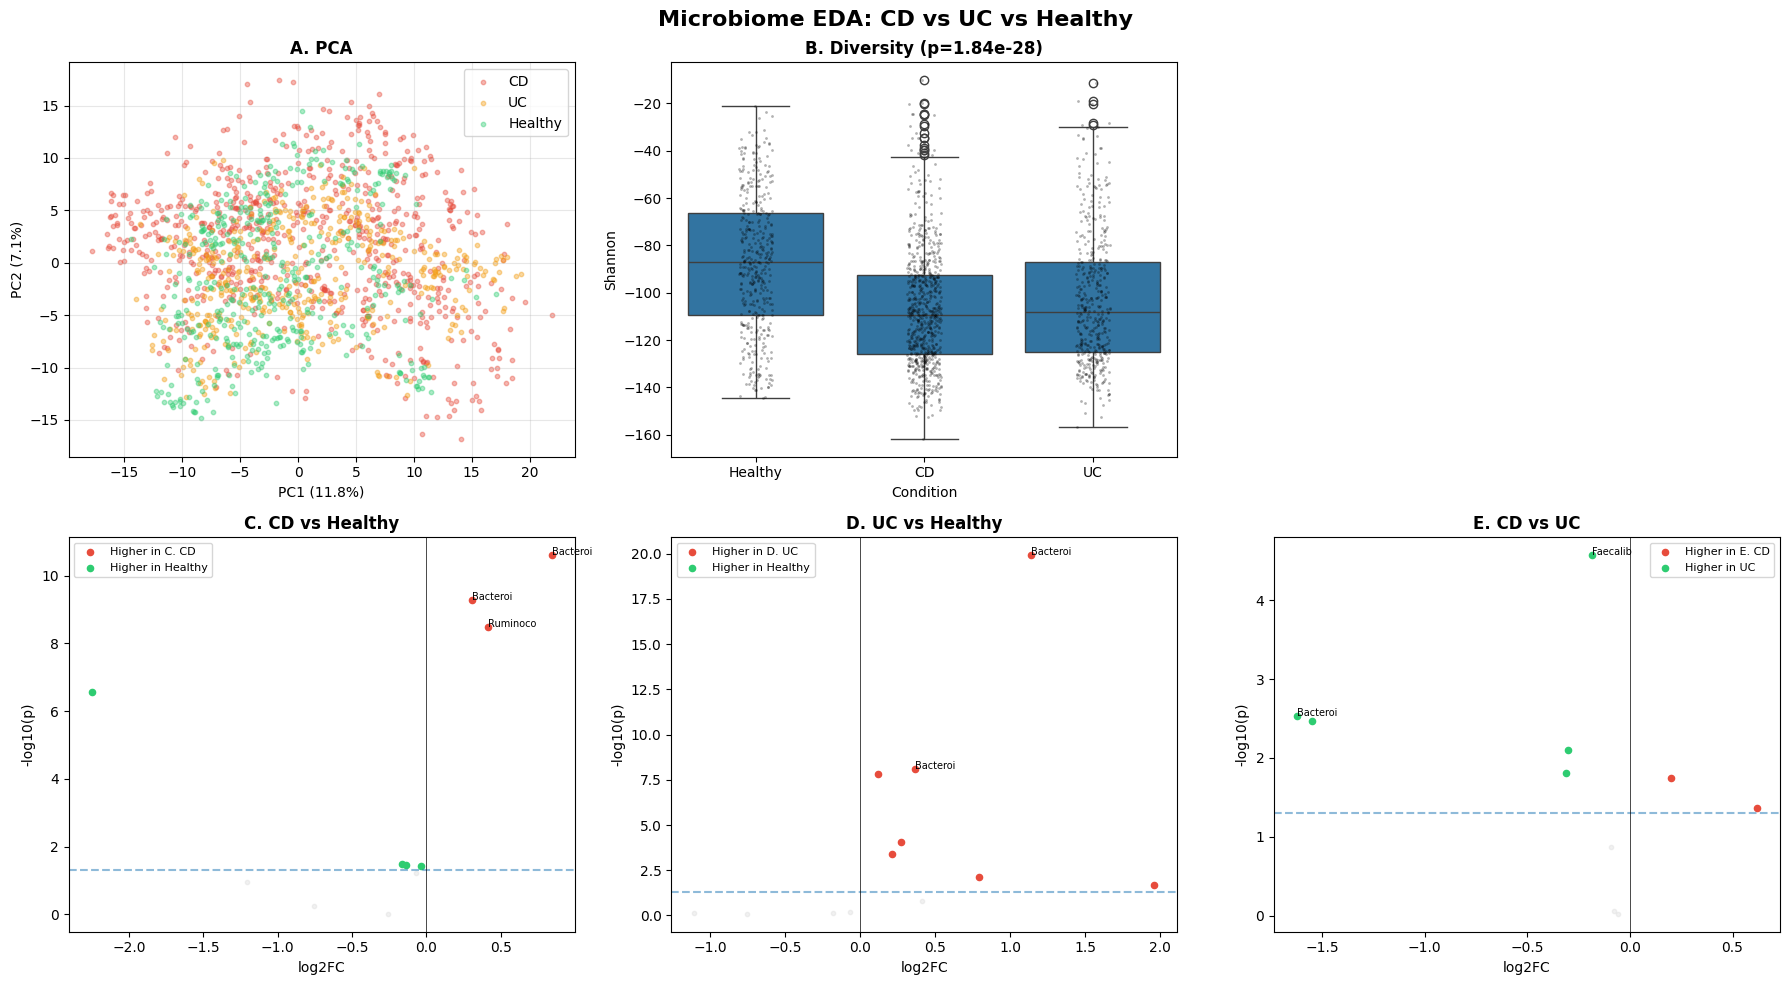

Figure saved & EDA complete


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from scipy.stats import kruskal, mannwhitneyu

cd = pd.read_csv("../data/processed/CD_CLR.csv", index_col=0)
uc = pd.read_csv("../data/processed/UC_CLR.csv", index_col=0)
h  = pd.read_csv("../data/processed/Healthy_CLR.csv", index_col=0)

cd['condition'] = 'CD'
uc['condition'] = 'UC'
h['condition']  = 'Healthy'

combined = pd.concat([cd, uc, h]).reset_index(drop=True)

features = combined.drop(columns=['condition']).fillna(0)
labels = combined['condition']

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(features)

colors = {'CD': '#e74c3c', 'UC': '#f39c12', 'Healthy': '#2ecc71'}

def shannon(row):
    p = row[row > 0]
    return -np.sum(p * np.log(p + 1e-10))

cd_sh = cd.drop(columns=['condition']).apply(shannon, axis=1)
uc_sh = uc.drop(columns=['condition']).apply(shannon, axis=1)
h_sh  = h.drop(columns=['condition']).apply(shannon, axis=1)

stat, pval = kruskal(cd_sh, uc_sh, h_sh)

def volcano(g1, g2, name, ax):

    results = []

    for sp in g1.columns:
        if sp not in g2.columns:
            continue

        if g1[sp].mean() < 1e-4 and g2[sp].mean() < 1e-4:
            continue

        try:
            _, p = mannwhitneyu(g1[sp], g2[sp])
        except:
            continue

        log2fc = np.log2((g1[sp].mean() + 1e-6) /
                         (g2[sp].mean() + 1e-6))

        results.append([sp, p, log2fc])

    df = pd.DataFrame(results, columns=['species','pval','log2FC'])
    df['-log10p'] = -np.log10(df['pval'] + 1e-300)

    df['sig'] = df['pval'] < 0.05

    ns = df[~df['sig']]
    hi = df[(df['sig']) & (df['log2FC'] > 0)]
    lo = df[(df['sig']) & (df['log2FC'] < 0)]

    ax.scatter(ns['log2FC'], ns['-log10p'],
               c='lightgrey', s=10, alpha=0.3)

    ax.scatter(hi['log2FC'], hi['-log10p'],
               c='#e74c3c', s=20, label='Higher in ' + name.split(' vs ')[0])

    ax.scatter(lo['log2FC'], lo['-log10p'],
               c='#2ecc71', s=20, label='Higher in ' + name.split(' vs ')[1])

    top = df.nsmallest(5, 'pval')
    for _, r in top.iterrows():
        ax.text(r['log2FC'], r['-log10p'],
                r['species'][:8], fontsize=7)

    ax.axhline(-np.log10(0.05), linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("log2FC")
    ax.set_ylabel("-log10(p)")
    ax.legend(fontsize=8)

    return df


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0,0]
for cond in ['CD','UC','Healthy']:
    mask = labels == cond
    ax.scatter(coords[mask,0], coords[mask,1],
               c=colors[cond], label=cond, alpha=0.4, s=10)

ax.set_title("A. PCA", fontweight='bold')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0,1]
div_df = pd.DataFrame({
    'Shannon': np.concatenate([h_sh, cd_sh, uc_sh]),
    'Condition': ['Healthy']*len(h_sh) + ['CD']*len(cd_sh) + ['UC']*len(uc_sh)
})

sns.boxplot(data=div_df, x='Condition', y='Shannon', ax=ax)
sns.stripplot(data=div_df, x='Condition', y='Shannon',
              color='black', size=2, alpha=0.3, ax=ax)

ax.set_title(f"B. Diversity (p={pval:.2e})", fontweight='bold')

axes[0,2].axis('off')

volcano(cd.drop(columns=['condition']),
        h.drop(columns=['condition']),
        "C. CD vs Healthy", axes[1,0])

volcano(uc.drop(columns=['condition']),
        h.drop(columns=['condition']),
        "D. UC vs Healthy", axes[1,1])

volcano(cd.drop(columns=['condition']),
        uc.drop(columns=['condition']),
        "E. CD vs UC", axes[1,2])

plt.suptitle("Microbiome EDA: CD vs UC vs Healthy",
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig("../figures/final/Fig1_EDA.png", dpi=300)
plt.show()

vol_cd_h.to_csv("../results/diff_CD_vs_Healthy.csv", index=False)
vol_uc_h.to_csv("../results/diff_UC_vs_Healthy.csv", index=False)
vol_cd_uc.to_csv("../results/diff_CD_vs_UC.csv", index=False)

print("Figure saved & EDA complete")

In [23]:
print("NaNs in features:", features.isna().sum().sum())

NaNs in features: 14350
